# **ESERCIZIO 12.1**

**OBIETTIVI**

L'obiettivo dell'esercizio 12.1 è usare modelli di reti neurali profonde (deep neural networks), implementati nel pacchetto Python Keras, per riconoscere e distinguere le dieci cifre scritte a mano (0–9) del dataset MNIST. Il dataset MNIST è formato da 70.000 immagini quadrate divise in una griglia di 28x28 pixel, dove ciascun pixel assume un valore di grigio compreso tra 0 e 255. Il dataset è già suddiviso in un set di training (60 000 campioni) e uno di test (10 000 campioni) per facilitare il confronto tra i modelli.

**IMPLEMENTAZIONE**

Prima di tutto, le immagini devono essere convertite da matrici 28×28 a vettori unidimensionali di 784 elementi, per adattarle all’ingresso di una rete neurale profonda (formata da più layers interconnessi). Dopodichè, i valori dei pixel sono stati normalizzati nell’intervallo $[0,1]$ dividendo per 255, al fine di velocizzare la convergenza dell'algoritmo, che in questo modo lavora in un range numerico limitato.

La rete neurale è stata costruita tramite il modello sequenziale di Keras, ovvero un modello in cui i layers vengono impilati uno dopo l'altro, in modo che l'output di un layer sia l'input del successivo. L’architettura è composta da due layer densi con attivazioni ReLU (formati da 400 e 100 neuroni), seguiti da un layer di Dropout per ridurre l’overfitting, e da un layer finale con attivazione softmax per produrre le probabilità delle 10 classi. In particolare:
 - in un layer denso ogni neurone è connesso a tutti i neuroni del livello precedente. L'attivazione ReLU introduce la non-linearità nel modello, permettendo alla rete di apprendere relazioni complesse.
 - un layer di Dropout durante l'addestramento "spegne" casualmente una percentuale di neuroni a ogni iterazione, costringendo la rete a non fare affidamento su nodi specifici e riducendo il rischio di overfitting (ovvero la tendenza del modello a memorizzare il dataset di training anziché generalizzare).
 - il layer finale con attivazione Softmax ha 10 nodi (ovvero uno per ogni cifra da 0 a 9). La funzione Softmax schiaccia l'output della rete trasformandolo in una distribuzione di probabilità, in cui il valore più alto indicherà la cifra predetta dal modello.

L’addestramento è stato eseguito per 20 epoche (numero sufficientemente grande da permettere di visualizzare l'evoluzione dei parametri al variare del numero di epoca) con batch size pari a 32 (ovvero il numero di campioni di dati che la rete analizza prima di aggiornare i propri pesi interni), mescolando l'ordine delle immagini del dataset a ogni epoca. Durante il training, il modello è stato valutato anche sul set di validation per monitorare la capacità di generalizzazione.

Infine, ho riportato il grafico dell'andamento di loss e accuracy su training e validation per ciascun ottimizzatore usato, per poter confrontare visivamente il comportamento dei diversi ottimizzatori.

In [1]:
#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True' #This is needed in my Anaconda+MacOsX installation; leave it commented.
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

In [2]:
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits (10 cifre)

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('X_train shape:', X_train.shape) #stampa dimensione datset
print('Y_train shape:', Y_train.shape)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)


In [3]:
# Consider an array of 5 labels out of a set of 3 classes {0, 1, 2}:
labels = np.array([0, 2, 1, 2, 0])
# `to_categorical` converts this into a matrix with as many columns as there are classes.
# The number of rows stays the same.
keras.utils.to_categorical(labels)

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

X_train shape: (60000, 784)
X_test shape: (10000, 784)

an example of a data point with label 4


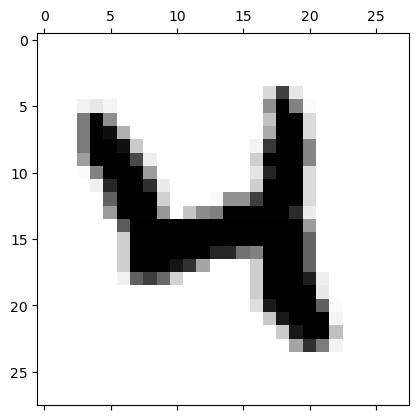

... and with label [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] after to_categorical

X_train shape: (60000, 784)
Y_train shape: (60000, 10)


In [4]:
# reshape data, it could depend on Keras backend
#trasformo le immagini in vettori perchè la rete richiede input vettoriale
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print()

# cast to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# rescale data in interval [0,1] 
#normalizzo pixels in intervallo 0-1
X_train /= 255
X_test /= 255

# look at an example of data point
print('an example of a data point with label', Y_train[20])
# matshow: display a matrix in a new figure window
plt.matshow(X_train[20,:].reshape(28,28),cmap='binary')
plt.show()

# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)
print('... and with label', Y_train[20], 'after to_categorical')
print()
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)

In [5]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

def create_DNN():
    # instantiate model - modello sequenziale: layer aggiunti uno dopo l'altro
    model = Sequential()
    # add a dense all-to-all relu layer
    model.add(Dense(400,input_shape=(img_rows*img_cols,), activation='relu'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer: trasforma le uscite in probabilità tra 0-1
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print('Model architecture created successfully!')

Model architecture created successfully!


In [6]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam

#funzione che crea e compila il modello neurale
def compile_model():
    # create the model
    model=create_DNN()
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=Adadelta(),
                  metrics=['acc']) #misura accuracy del modello
    return model

print('Model compiled successfully and ready to be trained.')

Model compiled successfully and ready to be trained.


Cambio il numero di epoche: provo ad aumentarle da 5 a 20.

In [7]:
# training parameters
batch_size = 32
epochs = 20

# create the deep neural net
model_DNN = compile_model()

# train DNN and store training info in history
history = model_DNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          verbose=1,
          validation_data=(X_test, Y_test))

/home/francy/ENTER/envs/Lab11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - acc: 0.1878 - loss: 2.2432 - val_acc: 0.3963 - val_loss: 2.1069
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.3076 - loss: 2.0774 - val_acc: 0.5337 - val_loss: 1.9467
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.4070 - loss: 1.9309 - val_acc: 0.6339 - val_loss: 1.7926
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - acc: 0.4778 - loss: 1.7945 - val_acc: 0.6972 - val_loss: 1.6451
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.5312 - loss: 1.6683 - val_acc: 0.7395 - val_loss: 1.5054
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - acc: 0.5744 - loss: 1.5501 - val_acc: 0.7701 - val_loss: 1.3761
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.6068 - loss: 1.4482 - val_acc: 0.7907 - val_loss: 1.2581
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.6378 - loss: 1.3474 - val_acc: 0.8082 - val_loss: 1.1515
Epoch 9/20
1875/1875 ━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8769 - loss: 0.5743

Test loss: 0.5743451714515686
Test accuracy: 0.8769000172615051


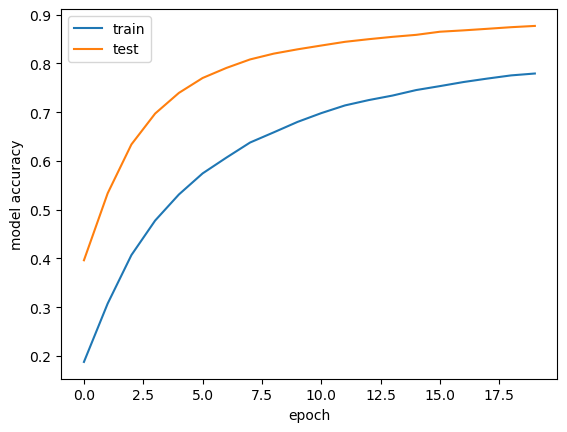

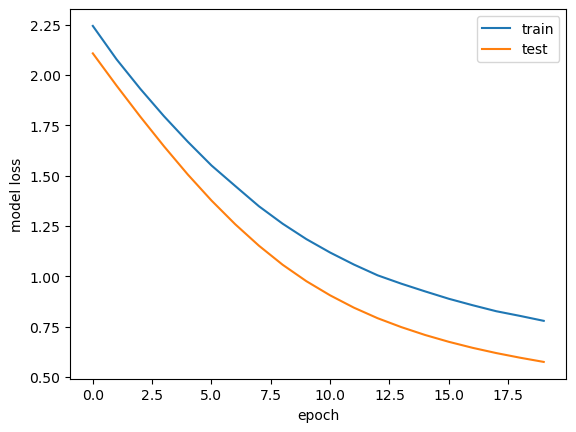

In [9]:
# evaluate model
score = model_DNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history

# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.ylabel('model accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


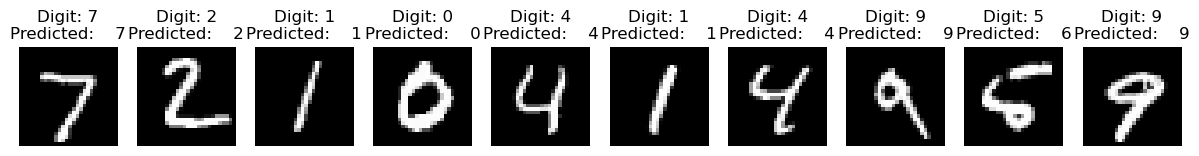

In [10]:
#X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
predictions = model_DNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

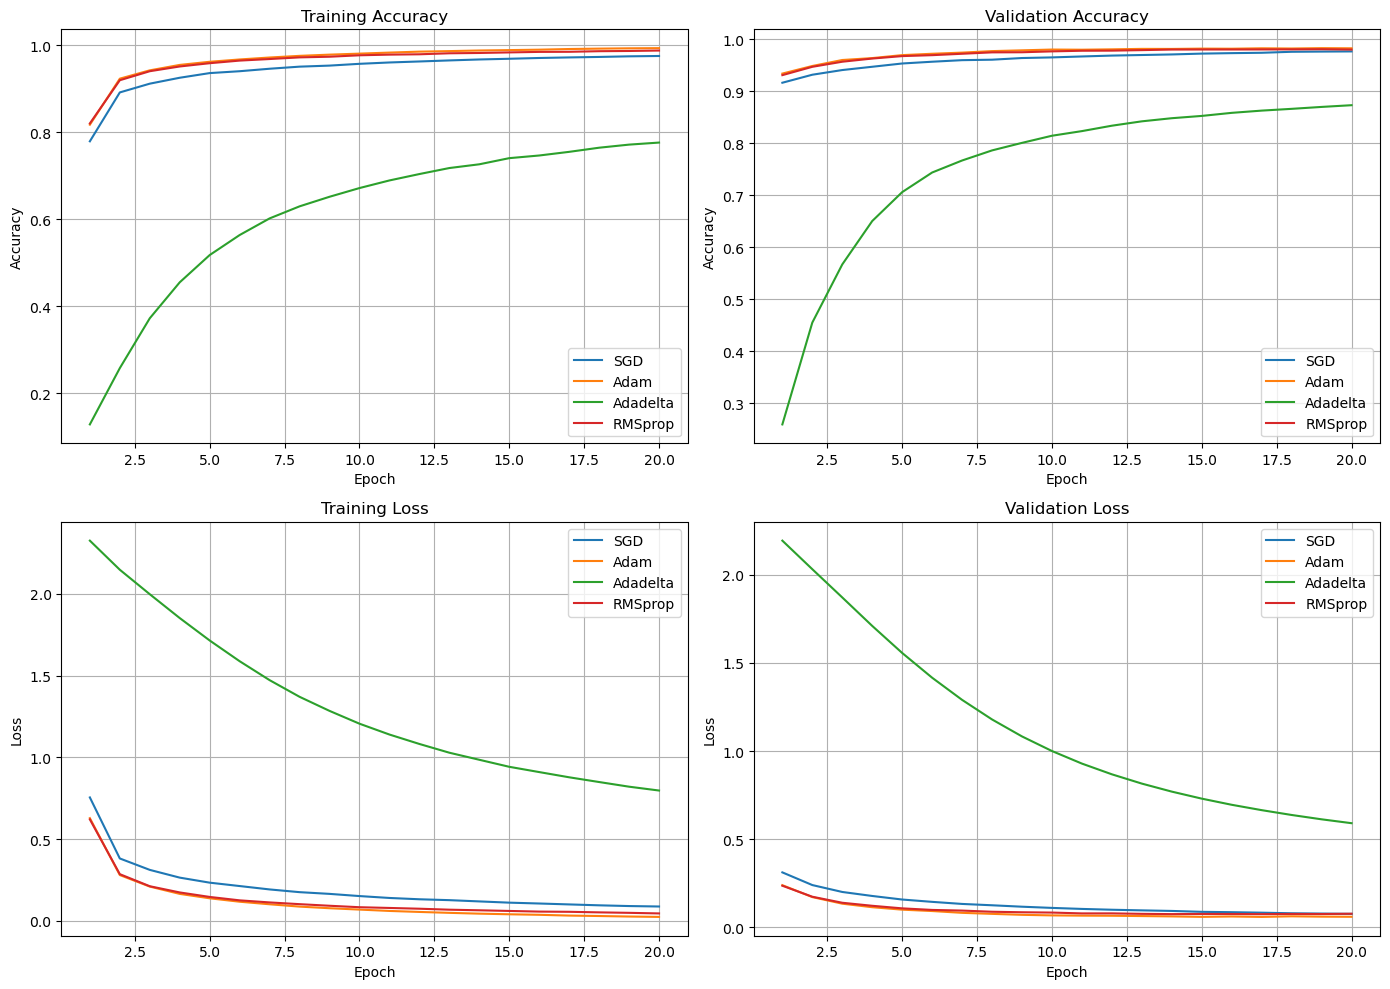

In [11]:
import matplotlib.pyplot as plt

#STMAPO TRAINING/VALIDATION LOSS E ACCURACY
sgd_acc = [
    0.7788, 0.8911, 0.9112, 0.9248, 0.9355,
    0.9398, 0.9455, 0.9503, 0.9527, 0.9568,
    0.9599, 0.9622, 0.9646, 0.9668, 0.9684,
    0.9702, 0.9715, 0.9726, 0.9740, 0.9748
]

sgd_val_acc = [
    0.9162, 0.9316, 0.9406, 0.9469, 0.9532,
    0.9566, 0.9596, 0.9605, 0.9637, 0.9649,
    0.9667, 0.9684, 0.9695, 0.9706, 0.9722,
    0.9731, 0.9738, 0.9757, 0.9761, 0.9764
]

sgd_loss = [
    0.7548, 0.3814, 0.3116, 0.2642, 0.2334,
    0.2127, 0.1920, 0.1753, 0.1648, 0.1514,
    0.1398, 0.1318, 0.1264, 0.1187, 0.1111,
    0.1059, 0.1003, 0.0948, 0.0903, 0.0876
]

sgd_val_loss = [
    0.3119, 0.2400, 0.2008, 0.1781, 0.1579,
    0.1447, 0.1329, 0.1253, 0.1172, 0.1104,
    0.1046, 0.1000, 0.0964, 0.0932, 0.0881,
    0.0861, 0.0833, 0.0799, 0.0782, 0.0765
]

adam_acc = [
    0.8169, 0.9227, 0.9418, 0.9543, 0.9615,
    0.9668, 0.9713, 0.9751, 0.9779, 0.9802,
    0.9826, 0.9848, 0.9860, 0.9874, 0.9883,
    0.9893, 0.9908, 0.9917, 0.9924, 0.9928
]

adam_val_acc = [
    0.9338, 0.9484, 0.9599, 0.9636, 0.9693,
    0.9719, 0.9741, 0.9770, 0.9785, 0.9800,
    0.9797, 0.9804, 0.9813, 0.9812, 0.9818,
    0.9816, 0.9824, 0.9820, 0.9827, 0.9824
]

adam_loss = [
    0.6281, 0.2799, 0.2094, 0.1647, 0.1377,
    0.1168, 0.1012, 0.0869, 0.0770, 0.0687,
    0.0604, 0.0543, 0.0487, 0.0438, 0.0400,
    0.0368, 0.0320, 0.0293, 0.0262, 0.0239
]

adam_val_loss = [
    0.2394, 0.1717, 0.1343, 0.1143, 0.1004,
    0.0926, 0.0824, 0.0766, 0.0711, 0.0679,
    0.0665, 0.0658, 0.0641, 0.0622, 0.0596,
    0.0617, 0.0593, 0.0627, 0.0608, 0.0600
]

adadelta_acc = [
    0.1285, 0.2578, 0.3723, 0.4549, 0.5175,
    0.5635, 0.6017, 0.6294, 0.6514, 0.6714,
    0.6889, 0.7036, 0.7174, 0.7260, 0.7401,
    0.7462, 0.7546, 0.7641, 0.7712, 0.7759
]

adadelta_val_acc = [
    0.2593, 0.4551, 0.5669, 0.6503, 0.7059,
    0.7436, 0.7667, 0.7861, 0.8006, 0.8143,
    0.8232, 0.8336, 0.8420, 0.8480, 0.8524,
    0.8583, 0.8626, 0.8660, 0.8697, 0.8730
]

adadelta_loss = [
    2.3257, 2.1477, 1.9980, 1.8521, 1.7149,
    1.5881, 1.4723, 1.3704, 1.2843, 1.2059,
    1.1396, 1.0819, 1.0284, 0.9852, 0.9422,
    0.9099, 0.8780, 0.8490, 0.8205, 0.7970
]

adadelta_val_loss = [
    2.1940, 2.0319, 1.8717, 1.7102, 1.5567,
    1.4163, 1.2906, 1.1795, 1.0832, 1.0004,
    0.9291, 0.8683, 0.8156, 0.7701, 0.7303,
    0.6954, 0.6650, 0.6376, 0.6130, 0.5910
]

rmsprop_acc = [
    0.8199, 0.9191, 0.9398, 0.9507, 0.9582,
    0.9642, 0.9678, 0.9716, 0.9731, 0.9764,
    0.9779, 0.9787, 0.9810, 0.9817, 0.9830,
    0.9842, 0.9844, 0.9858, 0.9863, 0.9873
]

rmsprop_val_acc = [
    0.9308, 0.9468, 0.9566, 0.9627, 0.9674,
    0.9692, 0.9719, 0.9746, 0.9748, 0.9765,
    0.9777, 0.9779, 0.9789, 0.9800, 0.9801,
    0.9801, 0.9802, 0.9803, 0.9806, 0.9799
]

rmsprop_loss = [
    0.6205, 0.2854, 0.2116, 0.1736, 0.1461,
    0.1252, 0.1125, 0.1019, 0.0921, 0.0832,
    0.0787, 0.0740, 0.0681, 0.0644, 0.0604,
    0.0564, 0.0551, 0.0517, 0.0488, 0.0452
]

rmsprop_val_loss = [
    0.2362, 0.1738, 0.1396, 0.1224, 0.1078,
    0.0989, 0.0952, 0.0886, 0.0857, 0.0839,
    0.0792, 0.0794, 0.0767, 0.0752, 0.0761,
    0.0759, 0.0750, 0.0761, 0.0757, 0.0774
]

epochs = list(range(1, 21))

plt.figure(figsize=(14, 10))

# training accuracy
plt.subplot(2, 2, 1)
plt.plot(epochs, sgd_acc, label="SGD")
plt.plot(epochs, adam_acc, label="Adam")
plt.plot(epochs, adadelta_acc, label="Adadelta")
plt.plot(epochs, rmsprop_acc, label="RMSprop")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

# validation accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs, sgd_val_acc, label="SGD")
plt.plot(epochs, adam_val_acc, label="Adam")
plt.plot(epochs, adadelta_val_acc, label="Adadelta")
plt.plot(epochs, rmsprop_val_acc, label="RMSprop")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

# training loss
plt.subplot(2, 2, 3)
plt.plot(epochs, sgd_loss, label="SGD")
plt.plot(epochs, adam_loss, label="Adam")
plt.plot(epochs, adadelta_loss, label="Adadelta")
plt.plot(epochs, rmsprop_loss, label="RMSprop")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# validation loss
plt.subplot(2, 2, 4)
plt.plot(epochs, sgd_val_loss, label="SGD")
plt.plot(epochs, adam_val_loss, label="Adam")
plt.plot(epochs, adadelta_val_loss, label="Adadelta")
plt.plot(epochs, rmsprop_val_loss, label="RMSprop")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**COMMENTO AI RISULTATI**

Ho provato ad eseguire diverse simulazioni, utilizzando un diverso numero di epoche e differenti ottimizzatori. Per tutte queste simulazioni, ho monitorato l'andamento della loss per training e validation.

*5 EPOCHE (ESEMPIO VISTO A LEZIONE)*

    loss: 0.2331 ---- val_loss: 0.1546

*20 EPOCHE*

- SGD: Usando l’ottimizzatore SGD, con il rate di apprendimento predefinito 0.001, la rete neurale apprende più lentamente rispetto ad Adam e RMSprop, ma training e validation risultano comunque molto regolari: la training accuracy e la validation accuracy aumentano gradualmente durante tutte le epoche, mentre training loss e validation loss diminuiscono in modo regolare e continuo. La validation accuracy cresce fino a circa 0.976, mentre la validation loss continua a diminuire fino all’ultima epoca (0.0765). SGD risulta quindi lento nella convergenza ma ugualmente robusto e stabile.

    
- ADAM: Per quanto riguarda Adam e RMSprop, ho usato un rate di apprendimento più basso, pari a 0.0001, per evitare l'overfitting.

    Adam mostra una convergenza molto rapida nelle prime epoche: la accuracy cresce velocemente e la loss diminuisce significativamente nelle prime 5–8 epoche. La validation accuracy raggiunge rapidamente valori elevati (0.98) e la validation loss diminuisce fino alle epoche 14–15 (0.059–0.062), poi è caratterizzata da piccole oscillazioni ma senza un aumento significativo. Con questo rate di apprendimento non si osserva overfitting: il gap tra training e validation cresce leggermente solo nelle fasi finali, ma in ogni caso la generalizzazione resta molto buona.


- RMSprop: Anche RMSprop converge rapidamente nelle prime epoche, con un andamento simile ad Adam. La validation accuracy raggiunge valori elevati (0.98) già a metà training, tuttavia la validation loss mostra oscillazioni impercettibilmente più evidenti rispetto ad Adam nella fase finale. Anche la validation accuracy rimane alta e stabile.

 
- ADADELTA: Usando l’ottimizzatore Adadelta, lasciando come rate di apprendimento quello predefinito, la rete neurale apprende in modo molto più lento rispetto ad Adam. Sia la training accuracy sia la validation accuracy aumentano gradualmente durante le epoche, mentre training loss e validation loss diminuiscono in maniera regolare e stabile, raggiungendo però dei valori poco performanti. Nel complesso le prestazioni finali risultano inferiori agli altri ottimizzatori: dopo 20 epoche la validation accuracy raggiunge solo 0.87 circa, valore molto lontano dal 0.98 ottenuto con Adam. Adadelta mostra quindi un apprendimento molto più lento ed meno efficace per il dataset MNIST, con dei risultati molto lontani da quelli ottenuti con gli altri ottimizzatori.

Quindi, per questo problema, anche al netto di un rate di apprendimento inferiore, Adam risulta l'ottimizzatore più efficace perchè riesce a convergere più rapidamente degli altri e a raggungere una migliore accuracy finale. RMSprop ottiene dei risultati simili ma con una stabilità inferiore. SGD richiede più tempo per apprendere ma generalizza molto bene, mentre senza dubbio Adadelta è l'ottimizzatore meno performante, dal momenot che converge molto lentamente e raggiunge un'accuracy di gran lunga inferiore rispetto agli altri metodi.

# **ESERCIZIO 12.2**

**OBIETTIVI**

L'obiettivo di questo esercizio consiste nel costruire e addestrare una Rete Neurale Convoluzionale (CNN), che, diversamente dalla DNN che tratta l'immagine come una semplice lista di pixel, è in grado di riconoscere le correlazioni spaziali locali (come ad esempio bordi e curve) e l'invarianza traslazionale (riconoscere una cifra anche se cambia posizione nell'immagine e non è centrata).

**IMPLEMENTAZIONE**

Per la CNN, i dati non devono più essere appiattiti in un vettore da 784 elementi, come invece era necessario per la DNN, ma devono mantenere la struttura a griglia 28x28. Inoltre, devo aggiugere un terzo parametro per il "canale" di colore (per il grigio è 1), e quindi si otterrà una forma del tipo (numero immagini, 28, 28, 1).

Nello specifico, devo modificare la funzione create_CNN(), utilizzando:
- Conv2D per estrarre le caratteristiche visive.
- MaxPooling2D per ridurre la dimensione dell'immagine e rendere il modello più efficiente.
- Dropout per evitare che la rete impari a memoria i dati di training (overfitting).
- Flatten per trasformare le mappe di pixel 2D in un vettore prima dello strato finale.
- Dense e Softmax per arrivare alla classificazione finale tra le 10 cifre.

Una volta definita la struttura, procedo con l'addestramento: come ottimizatore utilizzo lo SGD, e scelgo di usare 12 epoche, così che la rete abbia il tempo di imparare bene dai dati.

Infine utilizzo il metodo evaluate() per vedere come la CNN si comporta sui dati di test che non ha mai visto, e confronto le prestazioni della CNN con quelle della DNN dell'esercizio 12.1.

In [24]:
# you will need the following for Convolutional Neural Networks
from keras.layers import Flatten, Conv2D, MaxPooling2D

# reshape data, depending on Keras backend
if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols) #forma che dovrà avere l'input della rete
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)
    
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


In [25]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def create_CNN():
    #instantiate model
    model = Sequential() #creo modello sequenziale: output di un layer è input del successivo
    
    #add first convolutional layer with 10 filters (dimensionality of output space)
    model.add(Conv2D(10, kernel_size=(5, 5), #uso 10 filtri di dimensione 5x5 pixels per scansionare l'immagine
                     activation='relu', #introduco non linearità nel modello
                     input_shape=input_shape))
    
    #aggiungo un Max Pooling per dimezzare le dimensioni spaziali delle mappe di caratteristiche (aiuta la rete a diventare più resistente a traslazioni o distorsioni della cifra)
    model.add(MaxPooling2D(pool_size=(2, 2))) #sottocampionamento di 2x2 pixels dell'outputdella convoluzione, prendendone solo il valore massimo
    
    #aggiungo un secondo layer convoluzionale (aumento i filtri a 20 per catturare caratteristiche più complesse e eventuali combinazioni di forme)
    model.add(Conv2D(20, kernel_size=(5, 5), #uso venti filtri
                     activation='relu'))
    
    #secondo pooling e dropout per prevenire l'overfitting (come suggerito a lezione)
    model.add(MaxPooling2D(pool_size=(2, 2))) #sottocampionamento
    model.add(Dropout(0.25)) #spengo 25% neuroni per migliorare capacità di generalizzare: in questo modo la rete non dipende da percorsi specifici
    
    #appiattisco i dati in un vettore 1D per passare alla parte densa
    model.add(Flatten())
    
    #standard dense layer e secondo Dropout
    model.add(Dense(64, activation='relu')) #layer di 64 neuroni
    model.add(Dropout(0.5)) #spengo 50% neuroni
    
    #sfot max layer finale con num_classes=10 uscite: cifra "scelta" è quella con probabilità maggiore
    model.add(Dense(10, activation='softmax')) #layer di 10 neuroni
    
    #compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,  #conifugra processo di apprendimento del modello prima del fit
                  optimizer='SGD',
                  metrics=['acc'])
    
    return model

*TRAINING*

Dopo aver definito l'architettura della rete, creo il codice per eseguire training, validazione e visualizzazione grafica delle prestazioni del modello.

/home/francy/ENTER/envs/Lab11/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.6350 - loss: 1.0522 - val_acc: 0.9349 - val_loss: 0.2280
Epoch 2/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - acc: 0.8723 - loss: 0.4045 - val_acc: 0.9564 - val_loss: 0.1404
Epoch 3/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - acc: 0.9079 - loss: 0.3001 - val_acc: 0.9663 - val_loss: 0.1049
Epoch 4/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - acc: 0.9232 - loss: 0.2549 - val_acc: 0.9714 - val_loss: 0.0892
Epoch 5/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - acc: 0.9348 - loss: 0.2164 - val_acc: 0.9748 - val_loss: 0.0766
Epoch 6/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - acc: 0.9417 - loss: 0.1950 - val_acc: 0.9786 - val_loss: 0.0695
Epoch 7/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - acc: 0.9478 - loss: 0.1809 - val_acc: 0.9797 - val_loss: 0.0615
Epoch 8/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - acc: 0.9503 - loss: 0.1670 - val_acc: 0.9817 - val_loss: 0.0578
Epoch 9/12
1875/1875 ━━━━

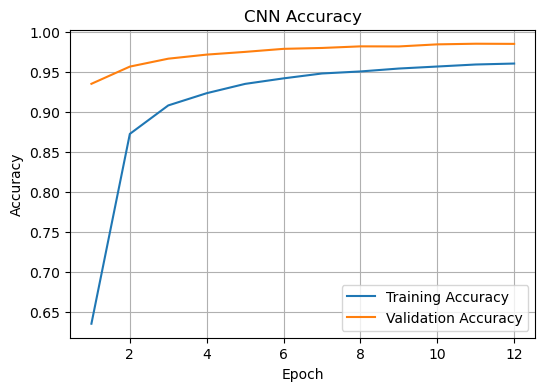

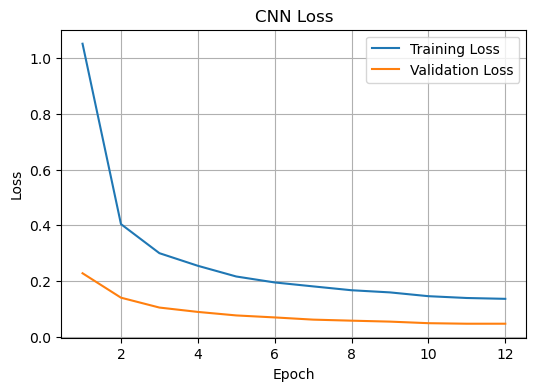

In [26]:
import matplotlib.pyplot as plt

#imposto i parametri della simulazione
batch_size = 32 #pesi della rete aggiornati ogni 32 immagini analizzate
epochs = 12 

# create the deep conv net
model_CNN = create_CNN() #creo la rete convoluzionale

# train CNN
history = model_CNN.fit(X_train, Y_train,
                        batch_size=batch_size,
                        epochs=epochs,
                        verbose=1,
                        validation_data=(X_test, Y_test))

# evaluate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1) #valuto il modello sul set di test

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])


#creo i grafici
#estraggo accuracy e loss
acc=history.history['acc']
val_acc=history.history['val_acc']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs_range=range(1, epochs+1)

#grafico accuracy
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#graficoo loss
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

**COMMENTO AI RISULTATI**

Quello che noto dai risultati numerici di train e loss (e dai grafiic) è che:
- LOSS: la loss è diminuita in modo costante e regolare, passando da circa 1.05 alla prima epoca a un valore finale sull'ultima epoca di 0.1362. In modo analogo la val_loss è passata da 0.2280 a 0.0469.
- ACCURACY: Il modello ha raggiunto un'accuracy finale sul test set del 98.48%. Inoltre, l'accuracy della validation risulta costantemente superiore a quella di training (98.48% contro 96% della training).

Questo comportamento è l'effetto dei layer di dropout inseriti: durante la fase di addestramento, il dropout disattiva casualmente una percentuale significativa di neuroni, rendendo il compito di classificazione volutamente più complesso per la rete; al contrario, durante la fase di validazione, il dropout viene automaticamente disattivato e la rete risponde al massimo delle sue potenzialità utilizzando tutti i canali neurali contemporaneamente.

Infine, analizzando i risultati ottenuti, la CNN si è dimostrata essere più efficiente della DNN, persino considerando tutte le 20 epoche della DNN e le sole 12 della CNN. Infatti, la CNN raggiunge una test accuracy di circa 98.5%, superiore a quella ottenuta dalla maggior parte delle configurazioni della DNN, e contemporaneamente riesce a mantenere una test loss molto contenuta. Questo risultato conferma che la CNN è la rete ottimale per l'elaborazione e il riconoscimento delle immagini: infatti attraverso i layer convoluzionali la rete è in grado di individuare caratteristiche come bordi e curve e non è sensibile alla traslazione. La DNN, invece, riceve in ingresso un semplice vettore di pixel e perde gran parte dell'informazione relativa alla struttura dell'immagine.

Quindi, per la classificazione di immagini come il dataset MNIST le reti CNN riescono a ottenere prestazioni migliori con un numero inferiore di epoche.

# **ESERCIZIO 12.3**

**OBIETTIVI**

L'obiettivo di questo esercizio consiste nel verificare la robustezza e la capacità di generalizzazione della rete neurale convoluzionale (CNN) che ho precedentemente addestrato, sottoponendola a un test di validazione con dati reali, ovvero con le 10 cifre scritte a mano usando GIMP.

**IMPLEMENTAZIONE**

- Per prima cosa carico le immagini delle 10 cifre, che voglio far riconoscere dalla rete, in una lista
- Successivamente ciclo sulle immagini caricate, convertendole in scala di grigi, in modo che ogni pixel diventi un valore tra 0 e 255
- Memorizzo le dimensioni delle immagini (28x28 pixels)
- Creo una matrice vuota per salvare l'immagine, dopodichè la riempio inserendo ogni pixel letto dall'immagine
- Normalizzo i valori originali dei pixels dividendo per 255, in modo che assumano valori tra 0 e 1, necessario affinchè l'input abbia la stessa scala usata durante l'addestramento della rete neurale
- Passo quindi l’immagine preprocessata al modello convoluzionale già addestrato, che restituisce un vettore di probabilità associato alle 10 cifre
- Seleziono la classe con probabilità massima utilizzando la funzione argmax, ottenendo così la cifra predetta dal modello
- Infine visualizzo le immagini insieme alla relativa predizione della rete

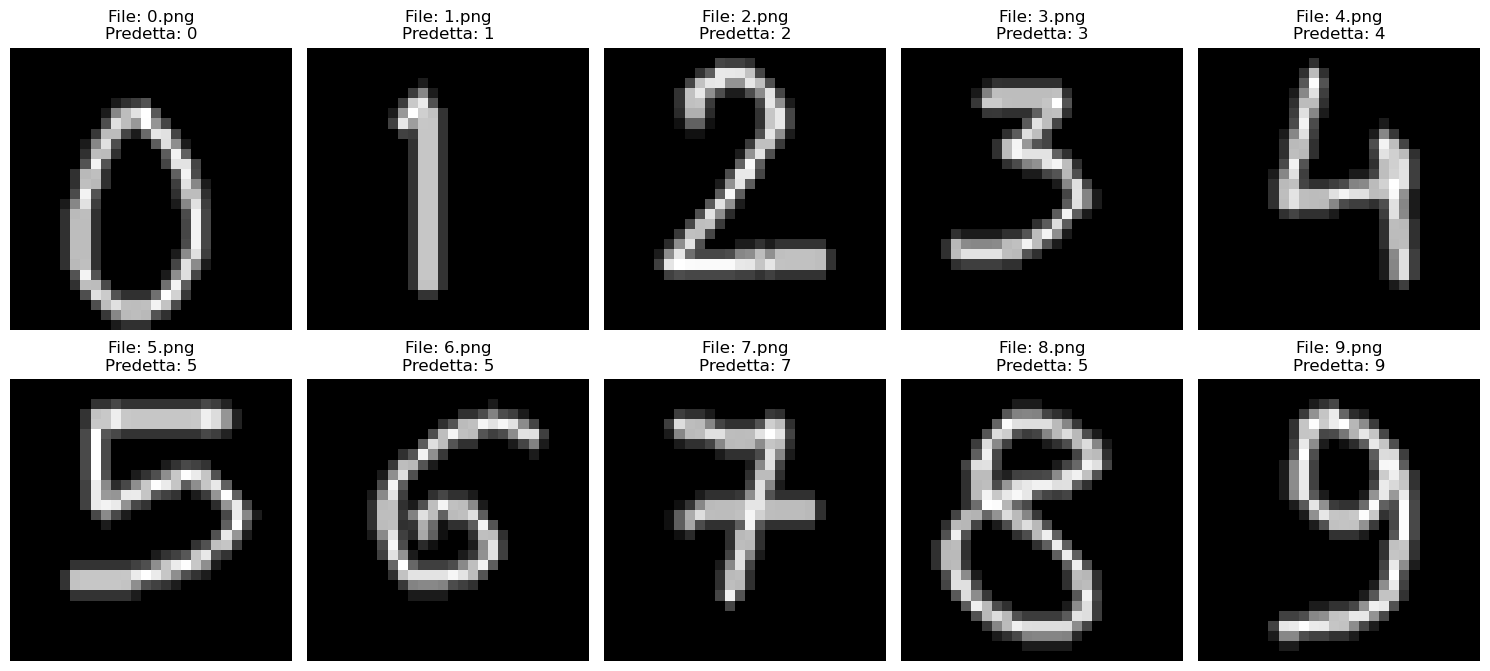

In [27]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

#carico le mie immagini delle 10 cifre in una lista
lista_immagini=["0.png","1.png","2.png","3.png","4.png","5.png","6.png","7.png","8.png","9.png"]


plt.figure(figsize=(15, 7))

for index, filename in enumerate(lista_immagini):
    try:
        #carico immagine e la converto in scala di grigi (L)
        digit_in=Image.open(filename).convert('L')
        ydim,xdim=digit_in.size
        
        #trasformo i pixel in una matrice
        pix=digit_in.load() #permette di leggere i pixels singolarmente
        data=np.zeros((xdim, ydim))
        for j in range(ydim):
            for i in range(xdim):
                data[i, j] = pix[j, i]
        
        #normalizzazione dei pixel tra 0 e 1
        data/=255.0
        
        #reshape per la CNN (la rete vuole la forma: 1 immagine, 28x28 pixel, 1 canale)
        data_cnn=data.reshape(1, xdim, ydim, 1)
        
        #predizione del modello convoluzionale
        prediction=model_CNN.predict(data_cnn, verbose=0)
        cifra_predetta=np.argmax(prediction) #prende la classe con probabilità più alta
        
        plt.subplot(2,5,index+1)
        plt.imshow(data, cmap='gray')
        plt.title(f"File: {filename}\nPredetta: {cifra_predetta}", fontsize=12)
        plt.axis('off')
        
    except FileNotFoundError:
        print(f"Errore: Il file '{filename}' non è stato trovato. Controlla il nome o il percorso!")

plt.tight_layout()
plt.show()

**COMMENTO AI RISULTATI**

Il modello CNN è riuscito a classificare correttamente quasi tutte le immagini che ho sottoposto al test, mostrando buone prestazioni nel riconoscimento delle cifre scritte a mano. In particolare, la rete dimostra una buona capacità di generalizzazione anche su dati esterni rispetto al dataset MNIST, confermando l’efficacia della struttura convoluzionale nell’estrazione delle caratteristiche rilevanti delle immagini.

Tuttavia, possiamo chiaramente notare un errore nella classificazione della cifra 8, che viene confusa con il 5. Questo tipo di errore è plausibile, ed è verosimilmente dovuto al fatto che le scritture manuali di queste due cifre possono presentare forme simili, ad esempio nella parte centrale o nella chiusura delle curve, rendendo difficile la distinzione anche per il modello.

Nel complesso, i risultati indicano un comportamento robusto della CNN, con un’elevata accuracy e un singolo errore (su un caso ambiguo), evidenziando comunque il limite del modello quando le caratteristiche visive tra classi diverse risultano poco distintive.

# **APPENDICE**

**SGD**

    
    Epoch 1/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.7788 - loss: 0.7548 - val_acc: 0.9162 - val_loss: 0.3119
    Epoch 2/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.8911 - loss: 0.3814 - val_acc: 0.9316 - val_loss: 0.2400
    Epoch 3/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9112 - loss: 0.3116 - val_acc: 0.9406 - val_loss: 0.2008
    Epoch 4/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9248 - loss: 0.2642 - val_acc: 0.9469 - val_loss: 0.1781
    Epoch 5/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9355 - loss: 0.2334 - val_acc: 0.9532 - val_loss: 0.1579
    Epoch 6/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9398 - loss: 0.2127 - val_acc: 0.9566 - val_loss: 0.1447
    Epoch 7/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9455 - loss: 0.1920 - val_acc: 0.9596 - val_loss: 0.1329
    Epoch 8/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9503 - loss: 0.1753 - val_acc: 0.9605 - val_loss: 0.1253
    Epoch 9/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9527 - loss: 0.1648 - val_acc: 0.9637 - val_loss: 0.1172
    Epoch 10/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9568 - loss: 0.1514 - val_acc: 0.9649 - val_loss: 0.1104
    Epoch 11/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9599 - loss: 0.1398 - val_acc: 0.9667 - val_loss: 0.1046
    Epoch 12/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9622 - loss: 0.1318 - val_acc: 0.9684 - val_loss: 0.1000
    Epoch 13/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9646 - loss: 0.1264 - val_acc: 0.9695 - val_loss: 0.0964
    Epoch 14/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9668 - loss: 0.1187 - val_acc: 0.9706 - val_loss: 0.0932
    Epoch 15/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9684 - loss: 0.1111 - val_acc: 0.9722 - val_loss: 0.0881
    Epoch 16/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - acc: 0.9702 - loss: 0.1059 - val_acc: 0.9731 - val_loss: 0.0861
    Epoch 17/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9715 - loss: 0.1003 - val_acc: 0.9738 - val_loss: 0.0833
    Epoch 18/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9726 - loss: 0.0948 - val_acc: 0.9757 - val_loss: 0.0799
    Epoch 19/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9740 - loss: 0.0903 - val_acc: 0.9761 - val_loss: 0.0782
    Epoch 20/20
    1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9748 - loss: 0.0876 - val_acc: 0.9764 - val_loss: 0.0765


**ADAM**

        Epoch 1/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.8169 - loss: 0.6281 - val_acc: 0.9338 - val_loss: 0.2394
        Epoch 2/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9227 - loss: 0.2799 - val_acc: 0.9484 - val_loss: 0.1717
        Epoch 3/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9418 - loss: 0.2094 - val_acc: 0.9599 - val_loss: 0.1343
        Epoch 4/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - acc: 0.9543 - loss: 0.1647 - val_acc: 0.9636 - val_loss: 0.1143
        Epoch 5/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9615 - loss: 0.1377 - val_acc: 0.9693 - val_loss: 0.1004
        Epoch 6/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9668 - loss: 0.1168 - val_acc: 0.9719 - val_loss: 0.0926
        Epoch 7/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.9713 - loss: 0.1012 - val_acc: 0.9741 - val_loss: 0.0824
        Epoch 8/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9751 - loss: 0.0869 - val_acc: 0.9770 - val_loss: 0.0766
        Epoch 9/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9779 - loss: 0.0770 - val_acc: 0.9785 - val_loss: 0.0711
        Epoch 10/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9802 - loss: 0.0687 - val_acc: 0.9800 - val_loss: 0.0679
        Epoch 11/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9826 - loss: 0.0604 - val_acc: 0.9797 - val_loss: 0.0665
        Epoch 12/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.9848 - loss: 0.0543 - val_acc: 0.9804 - val_loss: 0.0658
        Epoch 13/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9860 - loss: 0.0487 - val_acc: 0.9813 - val_loss: 0.0641
        Epoch 14/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9874 - loss: 0.0438 - val_acc: 0.9812 - val_loss: 0.0622
        Epoch 15/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - acc: 0.9883 - loss: 0.0400 - val_acc: 0.9818 - val_loss: 0.0596
        Epoch 16/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - acc: 0.9893 - loss: 0.0368 - val_acc: 0.9816 - val_loss: 0.0617
        Epoch 17/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - acc: 0.9908 - loss: 0.0320 - val_acc: 0.9824 - val_loss: 0.0593
        Epoch 18/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9917 - loss: 0.0293 - val_acc: 0.9820 - val_loss: 0.0627
        Epoch 19/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9924 - loss: 0.0262 - val_acc: 0.9827 - val_loss: 0.0608
        Epoch 20/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9928 - loss: 0.0239 - val_acc: 0.9824 - val_loss: 0.0600

**ADADELTA**

        Epoch 1/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.1285 - loss: 2.3257 - val_acc: 0.2593 - val_loss: 2.1940
        Epoch 2/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - acc: 0.2578 - loss: 2.1477 - val_acc: 0.4551 - val_loss: 2.0319
        Epoch 3/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.3723 - loss: 1.9980 - val_acc: 0.5669 - val_loss: 1.8717
        Epoch 4/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.4549 - loss: 1.8521 - val_acc: 0.6503 - val_loss: 1.7102
        Epoch 5/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - acc: 0.5175 - loss: 1.7149 - val_acc: 0.7059 - val_loss: 1.5567
        Epoch 6/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.5635 - loss: 1.5881 - val_acc: 0.7436 - val_loss: 1.4163
        Epoch 7/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.6017 - loss: 1.4723 - val_acc: 0.7667 - val_loss: 1.2906
        Epoch 8/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.6294 - loss: 1.3704 - val_acc: 0.7861 - val_loss: 1.1795
        Epoch 9/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - acc: 0.6514 - loss: 1.2843 - val_acc: 0.8006 - val_loss: 1.0832
        Epoch 10/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.6714 - loss: 1.2059 - val_acc: 0.8143 - val_loss: 1.0004
        Epoch 11/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.6889 - loss: 1.1396 - val_acc: 0.8232 - val_loss: 0.9291
        Epoch 12/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.7036 - loss: 1.0819 - val_acc: 0.8336 - val_loss: 0.8683
        Epoch 13/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.7174 - loss: 1.0284 - val_acc: 0.8420 - val_loss: 0.8156
        Epoch 14/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - acc: 0.7260 - loss: 0.9852 - val_acc: 0.8480 - val_loss: 0.7701
        Epoch 15/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.7401 - loss: 0.9422 - val_acc: 0.8524 - val_loss: 0.7303
        Epoch 16/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.7462 - loss: 0.9099 - val_acc: 0.8583 - val_loss: 0.6954
        Epoch 17/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.7546 - loss: 0.8780 - val_acc: 0.8626 - val_loss: 0.6650
        Epoch 18/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - acc: 0.7641 - loss: 0.8490 - val_acc: 0.8660 - val_loss: 0.6376
        Epoch 19/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - acc: 0.7712 - loss: 0.8205 - val_acc: 0.8697 - val_loss: 0.6130
        Epoch 20/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.7759 - loss: 0.7970 - val_acc: 0.8730 - val_loss: 0.5910
        

**RMSprop**

        Epoch 1/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.8199 - loss: 0.6205 - val_acc: 0.9308 - val_loss: 0.2362
        Epoch 2/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9191 - loss: 0.2854 - val_acc: 0.9468 - val_loss: 0.1738
        Epoch 3/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - acc: 0.9398 - loss: 0.2116 - val_acc: 0.9566 - val_loss: 0.1396
        Epoch 4/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - acc: 0.9507 - loss: 0.1736 - val_acc: 0.9627 - val_loss: 0.1224
        Epoch 5/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9582 - loss: 0.1461 - val_acc: 0.9674 - val_loss: 0.1078
        Epoch 6/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - acc: 0.9642 - loss: 0.1252 - val_acc: 0.9692 - val_loss: 0.0989
        Epoch 7/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9678 - loss: 0.1125 - val_acc: 0.9719 - val_loss: 0.0952
        Epoch 8/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.9716 - loss: 0.1019 - val_acc: 0.9746 - val_loss: 0.0886
        Epoch 9/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9731 - loss: 0.0921 - val_acc: 0.9748 - val_loss: 0.0857
        Epoch 10/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9764 - loss: 0.0832 - val_acc: 0.9765 - val_loss: 0.0839
        Epoch 11/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.9779 - loss: 0.0787 - val_acc: 0.9777 - val_loss: 0.0792
        Epoch 12/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9787 - loss: 0.0740 - val_acc: 0.9779 - val_loss: 0.0794
        Epoch 13/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9810 - loss: 0.0681 - val_acc: 0.9789 - val_loss: 0.0767
        Epoch 14/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9817 - loss: 0.0644 - val_acc: 0.9800 - val_loss: 0.0752
        Epoch 15/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.9830 - loss: 0.0604 - val_acc: 0.9801 - val_loss: 0.0761
        Epoch 16/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9842 - loss: 0.0564 - val_acc: 0.9801 - val_loss: 0.0759
        Epoch 17/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9844 - loss: 0.0551 - val_acc: 0.9802 - val_loss: 0.0750
        Epoch 18/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9858 - loss: 0.0517 - val_acc: 0.9803 - val_loss: 0.0761
        Epoch 19/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9863 - loss: 0.0488 - val_acc: 0.9806 - val_loss: 0.0757
        Epoch 20/20
        1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9873 - loss: 0.0452 - val_acc: 0.9799 - val_loss: 0.0774
